# EDA - Pandora18K

Analiza skupa: broj slika po klasi, dimenzije, aspect ratio, uzorci.

In [1]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

ROOT = Path("..")
DATA_DIR = ROOT / "Pandora_18k"
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tif", ".tiff"}

class_dirs = sorted([p for p in DATA_DIR.iterdir() if p.is_dir()])
print(f"Klasa: {len(class_dirs)}")
for c in class_dirs:
    print(" -", c.name)

Klasa: 18
 - 01_Byzantin_Iconography
 - 02_Early_Renaissance
 - 03_Northern_Renaissance
 - 04_High_Renaissance
 - 05_Baroque
 - 06_Rococo
 - 07_Romanticism
 - 08_Realism
 - 09_Impressionism
 - 10_Post_Impressionism
 - 11_Expressionism
 - 12_Symbolism
 - 13_Fauvism
 - 14_Cubism
 - 15_Surrealism
 - 16_AbstractArt
 - 17_NaiveArt
 - 18_PopArt


## Skupljanje putanja i dimenzija

In [2]:
rows = []
errors = []

for class_dir in class_dirs:
    label = class_dir.name
    for img_path in class_dir.rglob("*"):
        if not img_path.is_file() or img_path.suffix.lower() not in EXTS:
            continue
        try:
            with Image.open(img_path) as im:
                w, h = im.size
            rows.append({
                "path": str(img_path),
                "class": label,
                "width": w,
                "height": h,
                "aspect": w / h if h else np.nan,
            })
        except Exception as e:
            errors.append((str(img_path), str(e)))

df = pd.DataFrame(rows)
print(f"Ukupno slika: {len(df)}")
print(f"Greske pri citanju: {len(errors)}")
if errors[:3]:
    print(errors[:3])
df.head()

Ukupno slika: 18038
Greske pri citanju: 0


,path,class,width,height,aspect
0,../Pandora_18k/01_Byzantin_Iconography/Cimabue...,01_Byzantin_Iconography,277,500,0.554000
1,../Pandora_18k/01_Byzantin_Iconography/Cimabue...,01_Byzantin_Iconography,275,500,0.550000
2,../Pandora_18k/01_Byzantin_Iconography/Cimabue...,01_Byzantin_Iconography,400,499,0.801603
3,../Pandora_18k/01_Byzantin_Iconography/Cimabue...,01_Byzantin_Iconography,371,500,0.742000
4,../Pandora_18k/01_Byzantin_Iconography/Cimabue...,01_Byzantin_Iconography,289,500,0.578000


## Broj slika po klasi

class
01_Byzantin_Iconography     847
02_Early_Renaissance        751
03_Northern_Renaissance     821
04_High_Renaissance         832
05_Baroque                  990
06_Rococo                   832
07_Romanticism              895
08_Realism                 1199
09_Impressionism           1257
10_Post_Impressionism      1276
11_Expressionism           1027
12_Symbolism               1057
13_Fauvism                  719
14_Cubism                  1227
15_Surrealism              1072
16_AbstractArt             1063
17_NaiveArt                1053
18_PopArt                  1120
Name: count, dtype: int64
min/max: 719 1276


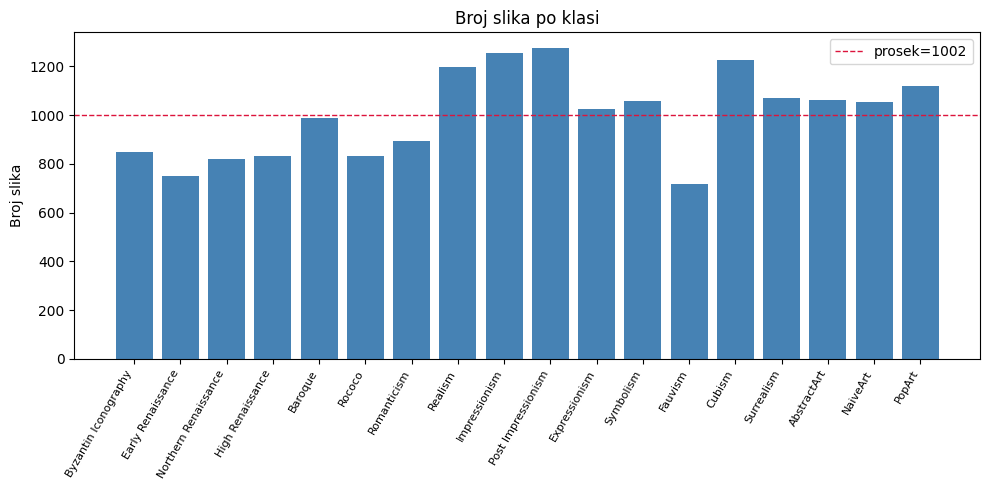

In [10]:
counts = df["class"].value_counts().sort_index()
print(counts)
print("min/max:", counts.min(), counts.max())

fig, ax = plt.subplots(figsize=(10, 5))
short = [c.split("_", 1)[1].replace("_", " ") if "_" in c else c for c in counts.index]
ax.bar(range(len(counts)), counts.values, color="steelblue")
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(short, rotation=60, ha="right", fontsize=8)
ax.set_ylabel("Broj slika")
ax.set_title("Broj slika po klasi")
ax.axhline(counts.mean(), color="crimson", linestyle="--", linewidth=1, label=f"prosek={counts.mean():.0f}")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "class_counts.png", dpi=150)
plt.show()

## Scatter: width × height

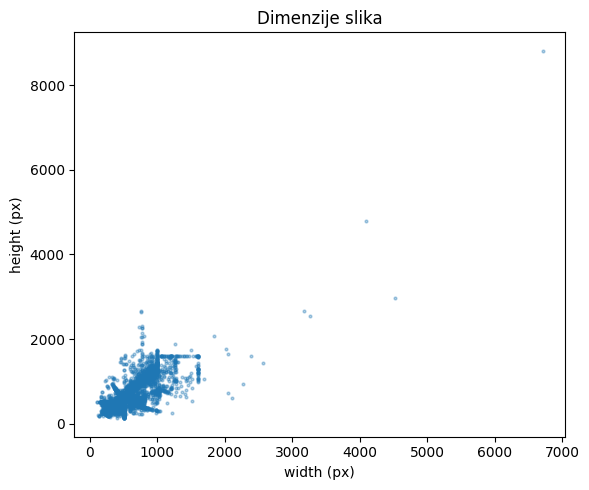

              width        height
count  18038.000000  18038.000000
mean     502.102340    525.914292
std      184.329399    222.896559
min      101.000000    125.000000
25%      396.000000    412.000000
50%      500.000000    500.000000
75%      500.000000    532.000000
max     6711.000000   8817.000000


In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df["width"], df["height"], s=4, alpha=0.35)
ax.set_xlabel("width (px)")
ax.set_ylabel("height (px)")
ax.set_title("Dimenzije slika")
fig.tight_layout()
fig.savefig(FIG_DIR / "size_scatter.png", dpi=150)
plt.show()

print(df[["width", "height"]].describe())

## Histogrami: sirina, visina, aspect ratio

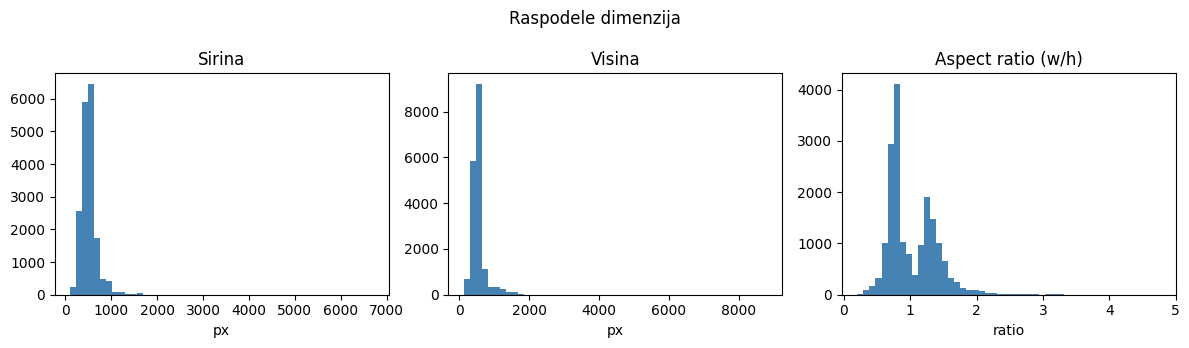

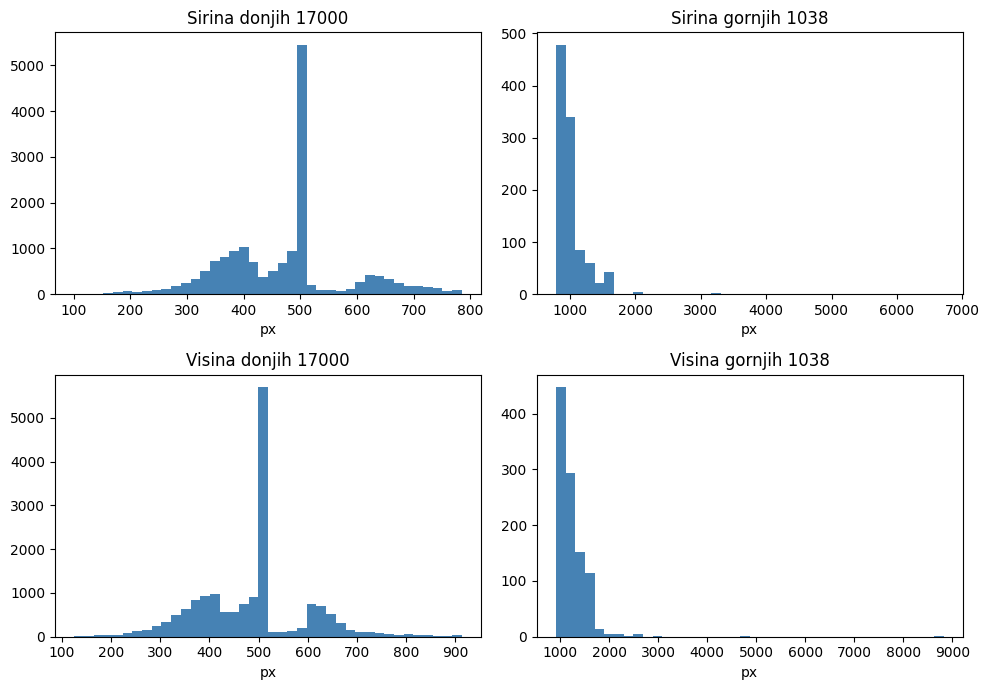

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

axes[0].hist(df["width"], bins=50, color="steelblue")
axes[0].set_title("Sirina")
axes[0].set_xlabel("px")

axes[1].hist(df["height"], bins=50, color="steelblue")
axes[1].set_title("Visina")
axes[1].set_xlabel("px")

axes[2].hist(df["aspect"].dropna(), bins=50, color="steelblue")
axes[2].set_title("Aspect ratio (w/h)")
axes[2].set_xlabel("ratio")

fig.suptitle("Raspodele dimenzija")
fig.tight_layout()
fig.savefig(FIG_DIR / "size_histograms.png", dpi=150)
plt.show()

w_sorted = np.sort(df["width"].values)
h_sorted = np.sort(df["height"].values)
n_low = 17000

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes[0, 0].hist(w_sorted[:n_low], bins=40, color="steelblue")
axes[0, 0].set_title(f"Sirina donjih {n_low}")
axes[0, 1].hist(w_sorted[n_low:], bins=40, color="steelblue")
axes[0, 1].set_title(f"Sirina gornjih {len(w_sorted) - n_low}")
axes[1, 0].hist(h_sorted[:n_low], bins=40, color="steelblue")
axes[1, 0].set_title(f"Visina donjih {n_low}")
axes[1, 1].hist(h_sorted[n_low:], bins=40, color="steelblue")
axes[1, 1].set_title(f"Visina gornjih {len(h_sorted) - n_low}")
for ax in axes.ravel():
    ax.set_xlabel("px")
fig.tight_layout()
fig.savefig(FIG_DIR / "size_histograms_split.png", dpi=150)
plt.show()

## Grid uzoraka (1 po klasi)

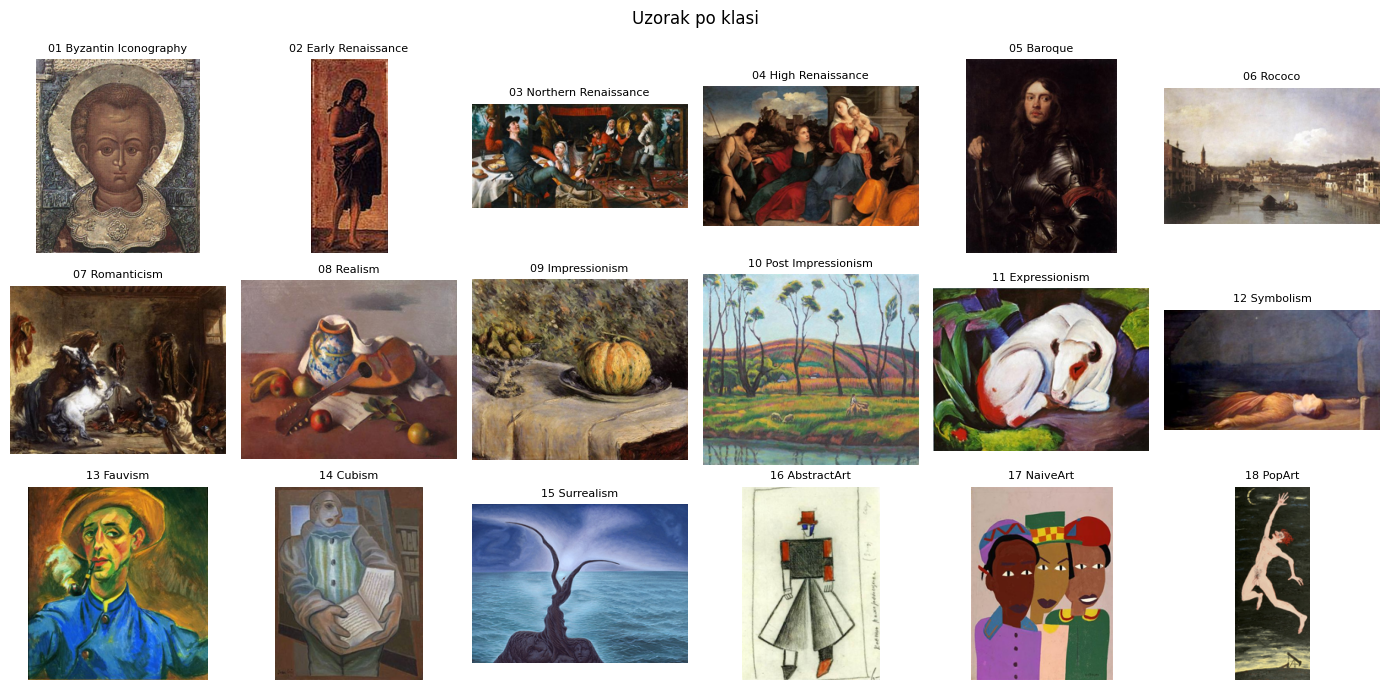

In [8]:
random.seed(42)

samples = []
for class_name, g in df.groupby("class", sort=True):
    row = g.sample(1, random_state=42).iloc[0]
    samples.append(row)

n = len(samples)
ncols = 6
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 7))
axes = np.array(axes).reshape(nrows, ncols)

for i, ax in enumerate(axes.ravel()):
    ax.axis("off")
    if i >= n:
        continue
    row = samples[i]
    im = Image.open(row["path"]).convert("RGB")
    # malo smanjimo za prikaz
    im.thumbnail((256, 256))
    ax.imshow(im)
    title = row["class"].split("_", 1)[1].replace("_", " ")
    ax.set_title(f"{i+1:02d} {title}", fontsize=8)

fig.suptitle("Uzorak po klasi", fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "sample_grid.png", dpi=150)
plt.show()

## Kratak zakljucak

In [12]:
print("Ukupno:", len(df))
print("Klasa:", df["class"].nunique())
print("Medijana width x height:", int(df["width"].median()), "x", int(df["height"].median()))
print("Medijana aspect:", round(df["aspect"].median(), 3))
print(list(FIG_DIR.glob("*.png")))

Ukupno: 18038
Klasa: 18
Medijana width x height: 500 x 500
Medijana aspect: 0.86
[PosixPath('../reports/figures/class_counts.png'), PosixPath('../reports/figures/size_histograms.png'), PosixPath('../reports/figures/size_histograms_split.png'), PosixPath('../reports/figures/sample_grid.png'), PosixPath('../reports/figures/size_scatter.png')]
